Requirements
- Cool 354g (12 fl oz) water from 71C (160F) to 4C (39F)
- Length <= 10" (minimize)
- Width <= 4"
- Depth <= 3"
- Ambient temp assumed to be 25C
- Freezer temp assumed to be -18C (0F)

In [ ]:
%reset -f
import numpy as np
import matplotlib.pyplot as plt


##Inputs
max_height = 12*25.4 #mm
max_width = 4*25.4 #mm
max_depth = 16+16+19 #mm
mass_w = 350 #g, 12 fl oz

#Temperatures
T_freezer = -18
water_starting_temp = 70 #C
water_final_temp = 4 #C
T_amb = 25

#Channel properties
channel_width = 1 #mm; machining constraint
channel_wall = 1.5 #mm; machining constraint
channel_depth = 1.5 #mm; starting point



## Water Properties 

In [903]:
mass_w = mass_w/1000 #kg
rho_water = 983 #kg/m3


mu=0.0006791 #Pa*s @ average temp = (70+6/2) = 
 
cp_w = 4180 #J/kg*K @ 60C.  
k_water = 0.61 #W/mK




## Block Properties
### 6061 Aluminum

In [904]:
block_volume = max_depth*max_height*max_width
#6061 Aluminum 
rho_al = 2700 #kg/m^3
k_al = 200 #W/mK
# Thermal
cp_al = 897 #J/(kg*K); 6061 Al
k_al = 175 #W/m*K
mass_al = rho_al*(block_volume/1e9) 
print(mass_al)


#n_channels = floor(max_width / (channel_wall + channel_width))

hydraulic_diameter = 4*channel_width*channel_depth / (2*channel_width + 2*channel_depth)
radius = (hydraulic_diameter/2)/1e3 #meters
Lc = hydraulic_diameter/1000 #Characterstic length, hydraulic diameter in m


4.013411327999999


Now, we must determine the minimum mass of the alumimnum block to have enough energy. 

In [905]:
Q_water = mass_w*cp_w *(water_starting_temp-water_final_temp)
print("Water : {:.2} J".format(Q_water))

Q_al = mass_al * cp_al * (water_final_temp - T_freezer)
print("Al : {:.2} J".format(Q_al))


Water : 9.7e+04 J
Al : 7.9e+04 J


Now that we have the mass of the aluminum block figured out, we can model how long it will take for the water to be cooled down. This will determine the channel design and how much we will need to slow down the water

## Heat Transfer ##

In [906]:
#Re = rho_water*avg_velocity*(hydraulic_diameter*1e-3)/mu

#entrance_length = 0.05*Re*Lc#meters


Nu_d = 3.657 #fully developed flow

h = Nu_d * k_water / Lc

print("{:.3}".format(h))

Bi = h*Lc / k_al #make sure Biot is less than 0.1

if(Bi < 0.1):
    print("Lumped model assumption valid!")



1.86e+03
Lumped model assumption valid!


Need to find the total area needed to transfer this much heat.

Do a first pass estimate


In [907]:
#Q = UA Tf-Ti

#area_hx = -Q_water/(h*(water_final_temp-water_starting_temp)) #m^2
#print(area_hx)


a_channel = max_height*(2*channel_width+2*channel_depth)
a_channel = a_channel / 1e6 #m2

#print(a_channel)

available_width = max_width - 6 #fixed offset for edges

num_channels = np.floor(available_width / (channel_wall + channel_width))
print(num_channels)

n_sides = 4 #number of channel arrays (?)

total_area = n_sides*num_channels*a_channel
print(total_area) #m2


38.0
0.23164799999999997


## Diffy Qs

Newton's law of cooling: q=h*dT

Water and Aluminum temps change each step:

Water ODE: mass_w*cp_w*dTw_dt=-h*A(Tw-Tal) -> dTw_dt = -h*A*(Tw-Tal) / mass_w*cp_w
Al temp: mass_al*cp_al*dTal_dt=h*A(Tw-Tal) - > dTal_dt = h*A*(Tw-Tal) / mass_al * cp_al


15.0
final temp
7.383462021099573


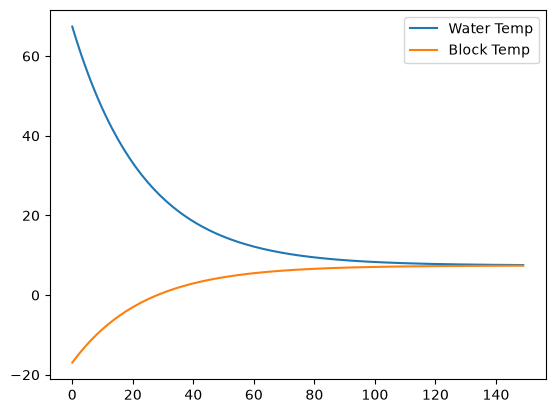

convergence reached at step 77
Time: 7.7


In [908]:
dt = 0.1
n_steps = 150


epsilon = 0.1 #convergence threshold, degC

def evaluate(state):

    Tw = temps[0]
    Tal = temps[1]
    dTw_dt = -h*total_area*(Tw - Tal) / (mass_w*cp_w)

    dTal_dt = h*total_area*(Tw - Tal) / (mass_al * cp_al)

    #print(Tw - Tal)
    return np.array([dTw_dt, dTal_dt])

temps = np.array([water_starting_temp, T_freezer])

water_arr = []
al_arr = []

for step in range(n_steps):
    temps = temps + dt*evaluate(temps)
    water_arr.append(temps[0])
    al_arr.append(temps[1])
   

total_time=n_steps*dt
print(total_time)

print("final temp")
print(al_arr[-1])


x = range(n_steps)

plt.plot(x, water_arr, label = "Water Temp")
plt.plot(x, al_arr, label = "Block Temp")

plt.legend()
plt.show()  

#convergence
for n in range(1, len(al_arr)):
    if abs(al_arr[n] - al_arr[n-1]) <= epsilon and abs(water_arr[n] - water_arr[n-1]) <= epsilon:

        print(f"convergence reached at step {n}")
        print(f"Time: {n*dt}")
        break


Water Speed Properties

In [909]:
g = 9.81 #m/s
radius = (hydraulic_diameter/2)/1e3 #meters

avg_velocity = rho_water*g*(radius**2)/(8*mu)

A_cs = num_channels*channel_depth*channel_width / 1e6

Q_flow = avg_velocity*A_cs

total_drain_time = (mass_w/1000) / Q_flow

print("Velocity: ")
print(avg_velocity)
print(" m/s")

#time = (max_height/1000)/avg_velocity

print(total_drain_time)
print(" sec")

Velocity: 
0.6390006626417317
 m/s
9.609302832031162
 sec
